In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

LOAD DATA

In [2]:
d1=pd.read_csv(r"C:\Users\Hi\Downloads\clean_1_train.csv")
d1.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


Data understanding and Exploration

In [3]:
d1.shape

(8519, 12)

In [4]:
d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8519 entries, 0 to 8518
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8519 non-null   object 
 1   Item_Weight                8519 non-null   float64
 2   Item_Fat_Content           8519 non-null   object 
 3   Item_Visibility            8519 non-null   float64
 4   Item_Type                  8519 non-null   object 
 5   Item_MRP                   8519 non-null   float64
 6   Outlet_Identifier          8519 non-null   object 
 7   Outlet_Establishment_Year  8519 non-null   int64  
 8   Outlet_Size                8519 non-null   object 
 9   Outlet_Location_Type       8519 non-null   object 
 10  Outlet_Type                8519 non-null   object 
 11  Item_Outlet_Sales          8519 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 798.8+ KB


In [5]:
d1.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [6]:
d1.pivot_table(values='Item_Outlet_Sales',index='Outlet_Type')

,Item_Outlet_Sales
Outlet_Type,
Grocery Store,340.031198
Supermarket Type1,2316.181148
Supermarket Type2,1995.498739
Supermarket Type3,3695.781505


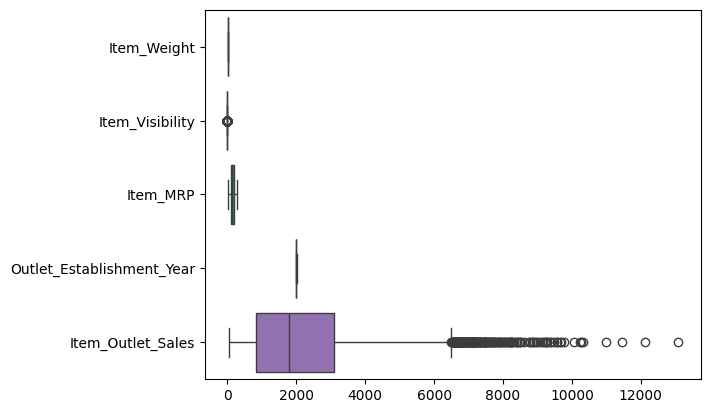

In [7]:
sns.boxplot(data=d1,orient='h')
plt.show()

<Axes: >

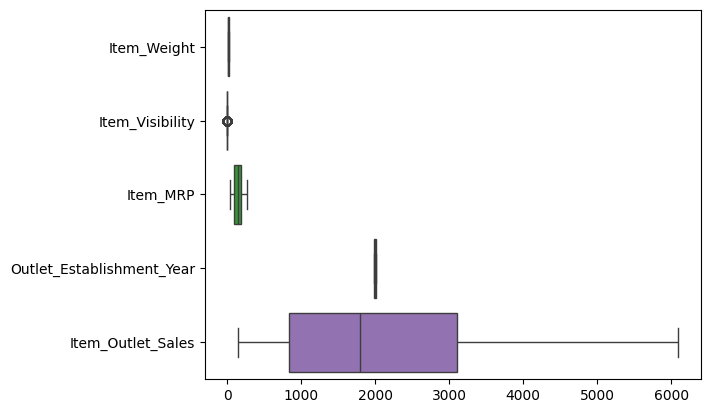

In [8]:
from scipy.stats.mstats import winsorize
d1['Item_Outlet_Sales']=winsorize(d1['Item_Outlet_Sales'],limits=(0.03,0.03))
sns.boxplot(data=d1,orient='h')

In [9]:
d1["Item_Visibility"].describe()

count    8519.000000
mean        0.066112
std         0.051586
min         0.000000
25%         0.026983
50%         0.053925
75%         0.094558
max         0.328391
Name: Item_Visibility, dtype: float64

In [10]:
print('Frequency of Categories for varible Item Type')
d1['Item_Type'].value_counts()

Frequency of Categories for varible Item Type


Item_Type
Fruits and Vegetables    1232
Snack Foods              1199
Household                 910
Frozen Foods              855
Dairy                     681
Canned                    649
Baking Goods              647
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

Feature Engineering

In [11]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
categorical_cols=['Item_Fat_Content','Item_Type','Outlet_Size','Outlet_Location_Type','Outlet_Type','Outlet_Identifier']
for col in categorical_cols:
    d1[col]=le.fit_transform(d1[col])
d1

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,1,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,DRC01,5.920,2,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,FDN15,17.500,1,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,FDX07,19.200,2,0.000000,6,182.0950,0,1998,2,2,0,732.3800
4,NCD19,8.930,1,0.000000,9,53.8614,1,1987,0,2,1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8514,FDF22,6.865,1,0.056783,13,214.5218,1,1987,0,2,1,2778.3834
8515,FDS36,8.380,2,0.046982,0,108.1570,7,2002,2,1,1,549.2850
8516,NCJ29,10.600,1,0.035186,8,85.1224,6,2004,2,1,1,1193.1136
8517,FDN46,7.210,2,0.145221,13,103.1332,3,2009,1,2,2,1845.5976


In [12]:
def One_hot_encoding(d1):
    #One Hot Coding:
    d1 = pd.get_dummies(d1, columns=['Item_Fat_Content','Outlet_Location_Type','Outlet_Size','Outlet_Type','Item_Type'],drop_first = True)
    
    return d1

In [13]:
d1

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,1,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,DRC01,5.920,2,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,FDN15,17.500,1,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,FDX07,19.200,2,0.000000,6,182.0950,0,1998,2,2,0,732.3800
4,NCD19,8.930,1,0.000000,9,53.8614,1,1987,0,2,1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8514,FDF22,6.865,1,0.056783,13,214.5218,1,1987,0,2,1,2778.3834
8515,FDS36,8.380,2,0.046982,0,108.1570,7,2002,2,1,1,549.2850
8516,NCJ29,10.600,1,0.035186,8,85.1224,6,2004,2,1,1,1193.1136
8517,FDN46,7.210,2,0.145221,13,103.1332,3,2009,1,2,2,1845.5976


In [14]:
corr=d1.corr(numeric_only=True)

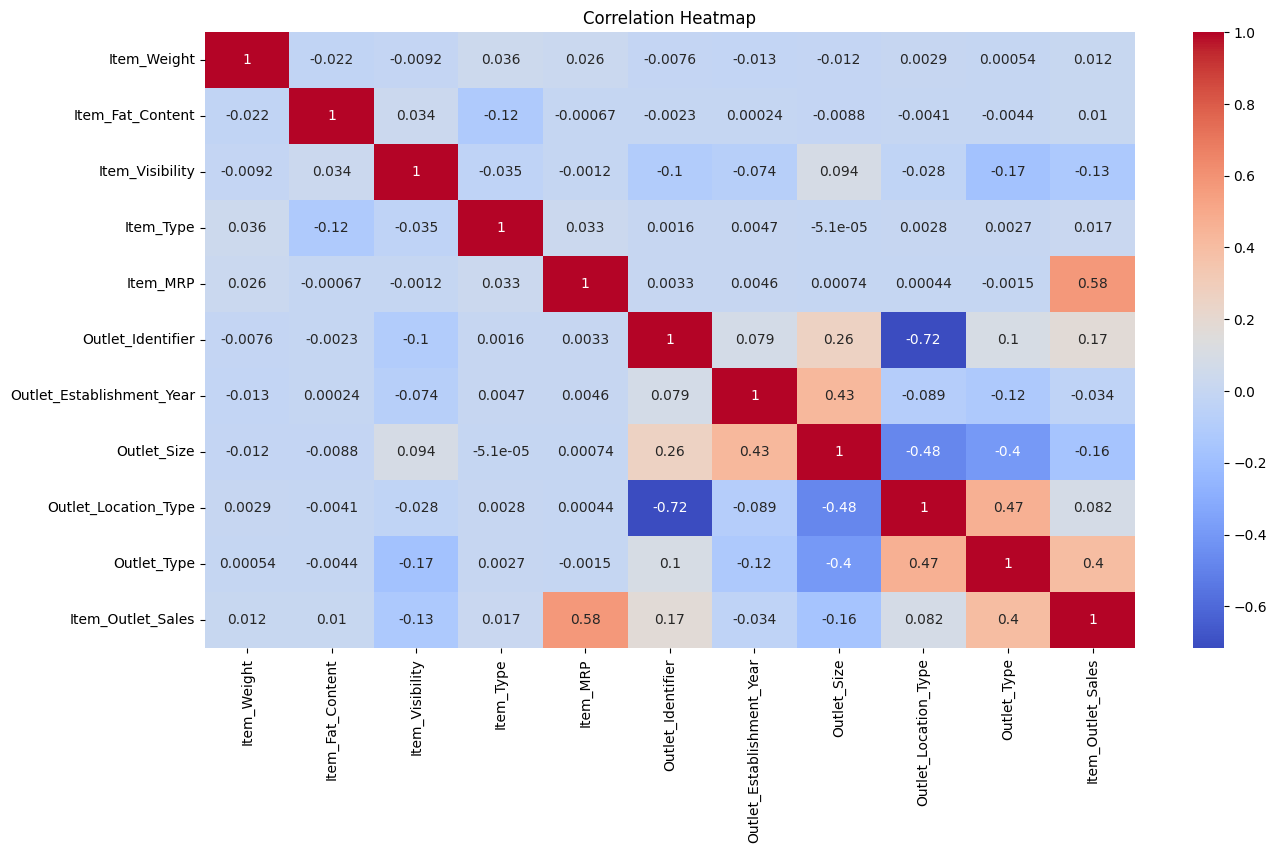

In [15]:
plt.figure(figsize=(15,8))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Visualization of Plots

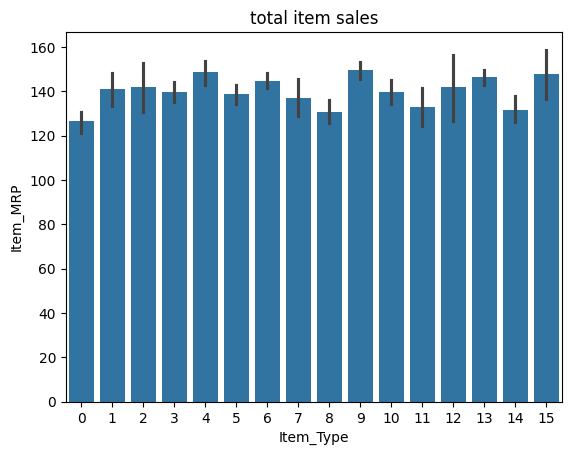

In [16]:
#BARPLOT
sns.barplot(x="Item_Type",y="Item_MRP",data=d1)
plt.title("total item sales")
plt.show()

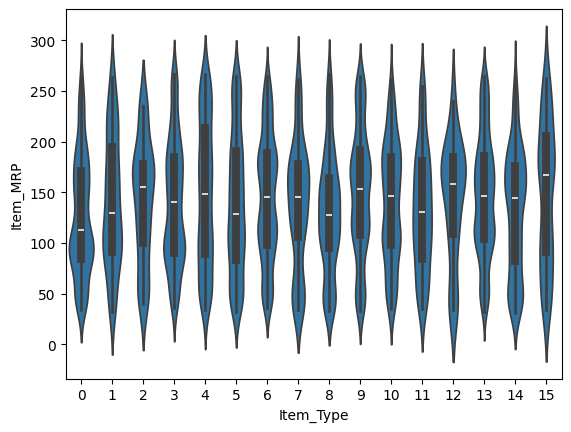

In [17]:
#violin plot
sns.violinplot(x="Item_Type",y="Item_MRP",data=d1)
plt.show()

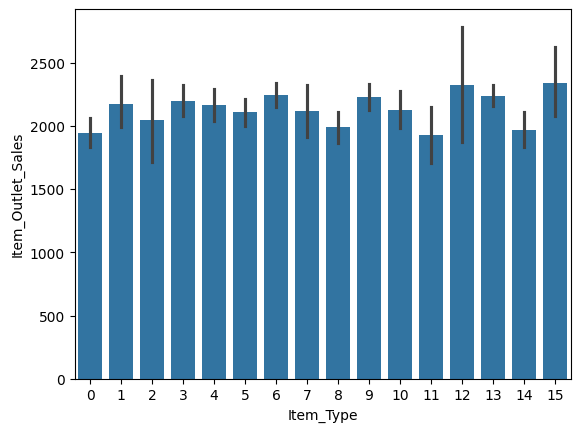

In [18]:
sns.barplot(x="Item_Type",y="Item_Outlet_Sales",data=d1)
plt.show()

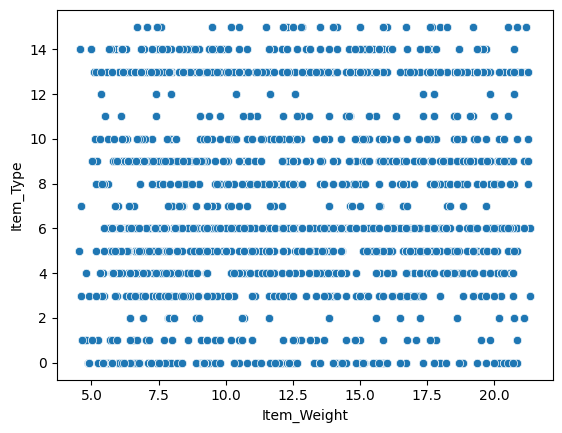

In [19]:
#scatter plot
sns.scatterplot(x="Item_Weight",y="Item_Type",data=d1)
plt.show()

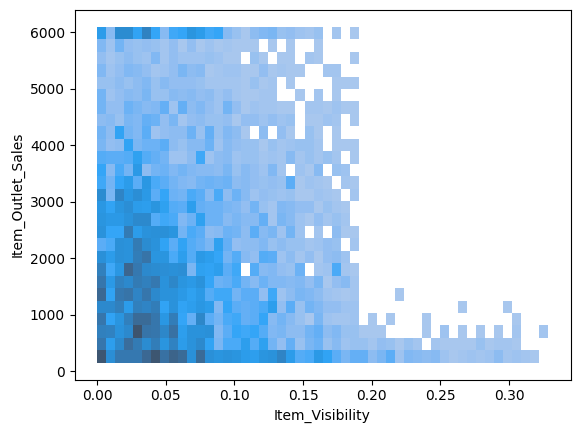

In [20]:
#hist plot
sns.histplot(x="Item_Visibility",y="Item_Outlet_Sales",data=d1)
plt.show()

Train-Test Split

In [21]:
x=d1.drop(columns=['Item_Fat_Content','Outlet_Location_Type','Outlet_Size','Outlet_Type','Item_Type'])
y=d1['Item_Outlet_Sales']

In [22]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

ValueError: could not convert string to float: 'FDS03'

In [ ]:
x_train.shape

(6815, 7)

In [ ]:
y_train.shape

(6815,)

In [ ]:
x_test.shape

(1704, 7)

In [ ]:
y_test.shape

(1704,)

Model Building (Regression)

In [ ]:
#Linear regressinon
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)

Model Evaluation

In [ ]:
from sklearn.metrics import r2_score,mean_squared_error
lr_r2 = r2_score(y_test,lr_pred)
lr_r2

1.0

Model Building

In [ ]:
#random forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200,random_state=42)

rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)

Model Evaluation

In [ ]:
rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2, rf_rmse

(0.9999996314691062, np.float64(0.9705828261044595))

In [ ]:
#decision tree
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor(criterion='squared_error')

dt.fit(x_train,y_train)
dt_pred=dt.predict(x_test)

In [ ]:
mse=mean_squared_error(y_test,dt_pred)
r2=r2_score(y_test,dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))

print("MSE:",mse)
print("R2 Score:",r2)
print("RSME:",dt_rmse)

MSE: 3.5020922146008986
R2 Score: 0.9999986299504543
RSME: 1.8713877777202934


In [ ]:
#XG Boost
from xgboost import XGBRegressor
model_xgb=XGBRegressor()
model_xgb.fit(x_train,y_train)

y_pred_xgb=model_xgb.predict(x_test)
print(y_pred_xgb)

[1317.445    558.43713  261.06866 ... 1379.5728   150.74126 3232.7373 ]


In [ ]:
mse=mean_squared_error(y_test,y_pred_xgb)
r2=r2_score(y_test,y_pred_xgb)

print("MSE:",mse)
print("R2 Score:",r2)

MSE: 108.27869155508262
R2 Score: 0.9999576404151918


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='r2'
)
grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)

best_rf = grid_search.best_estimator_

y_pred_rf = best_rf.predict(x_test)
print(y_pred_rf)

c:\Users\Hi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
540 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
277 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Hi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Hi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "c:\Users\Hi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 

Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
[1330.84879594  603.13802053  248.03469073 ... 1366.31819794  198.15027966
 3153.55621796]


In [ ]:
import joblib
joblib.dump(model_xgb,"xgbmodel")

['xgbmodel']